# Linear Regression - Complete Guide

## Overview
Linear regression is a fundamental supervised learning algorithm that models the linear relationship between independent variable(s) (X) and a dependent variable (Y).

**Equation:** $Y = \beta_0 + \beta_1 X + \epsilon$

Where:
- $\beta_0$ = intercept
- $\beta_1$ = slope/coefficient  
- $\epsilon$ = error term

## Key Assumptions
1. **Linearity**: Linear relationship between X and Y
2. **Independence**: Observations are independent
3. **Homoscedasticity**: Constant variance of residuals
4. **Normality**: Errors are normally distributed
5. **No Multicollinearity**: Independent variables aren't highly correlated

In [28]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

# Set style
sns.set_style("whitegrid")

## 1. Cost Function (Loss Function)

Uses Mean Squared Error:
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Minimizing MSE gives us the best-fit line.

In [29]:
# Generate Sample Data
np.random.seed(42)
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = 2.5 * X.flatten() + np.random.normal(0, 2, 10)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst 5 samples:\nX: {X[:5].flatten()}\ny: {y[:5]}")

X shape: (10, 1)
y shape: (10,)

First 5 samples:
X: [1 2 3 4 5]
y: [ 3.49342831  4.7234714   8.79537708 13.04605971 12.03169325]


## 2. Simple Linear Regression Implementation

In [30]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Get coefficients
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept (β₀): {intercept:.4f}")
print(f"Slope (β₁): {slope:.4f}")
print(f"\nEquation: y = {intercept:.4f} + {slope:.4f} * X")

# Make predictions
y_pred = model.predict(X)
print(f"\nFirst 5 predictions:\n{y_pred[:5]}")

Intercept (β₀): 0.9720
Slope (β₁): 2.4862

Equation: y = 0.9720 + 2.4862 * X

First 5 predictions:
[ 3.45822557  5.94442483  8.43062408 10.91682334 13.4030226 ]


## 3. Evaluation Metrics

In [31]:
# Calculate metrics
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print("=" * 40)
print("EVALUATION METRICS")
print("=" * 40)
print(f"R² Score: {r2:.4f}")
print(f"  → Explains {r2*100:.2f}% of variance")
print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print("=" * 40)

EVALUATION METRICS
R² Score: 0.9644
  → Explains 96.44% of variance

Mean Squared Error (MSE): 1.8803
Root Mean Squared Error (RMSE): 1.3712
Mean Absolute Error (MAE): 1.1473


## 4. Visualization

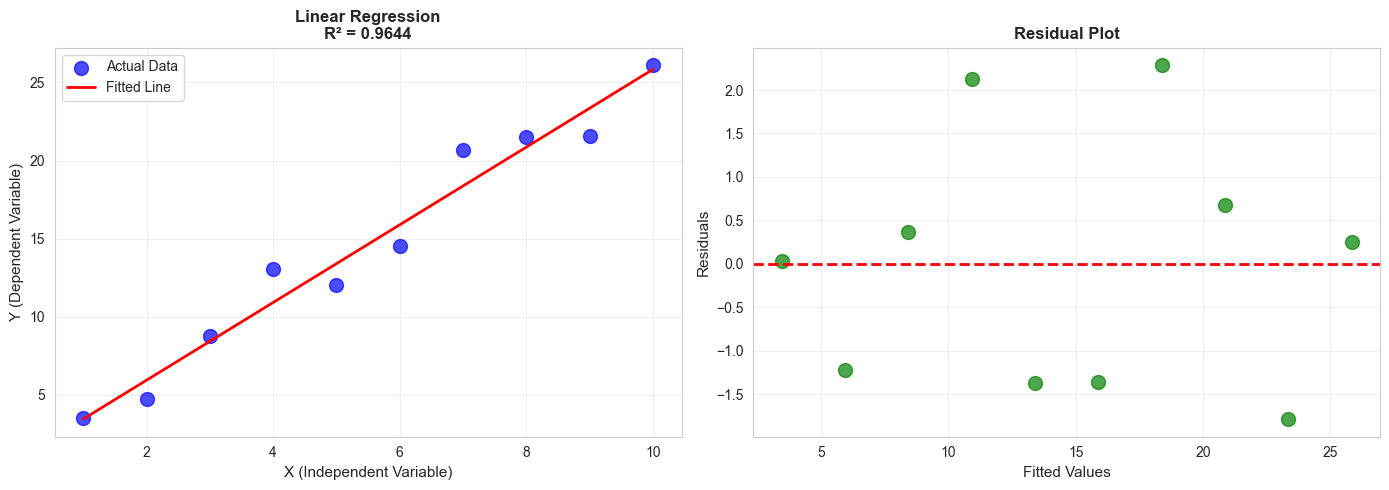

Residuals (Actual - Predicted):
[ 0.03520274 -1.22095343  0.36475299  2.12923637 -1.37132934 -1.35749577
  2.28300452  0.67324909 -1.78676839  0.25110121]


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression Line
axes[0].scatter(X, y, color='blue', s=100, label='Actual Data', alpha=0.7)
axes[0].plot(X, y_pred, color='red', linewidth=2, label='Fitted Line')
axes[0].set_xlabel('X (Independent Variable)', fontsize=11)
axes[0].set_ylabel('Y (Dependent Variable)', fontsize=11)
axes[0].set_title(f'Linear Regression\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y - y_pred
axes[1].scatter(y_pred, residuals, color='green', s=100, alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Fitted Values', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Residuals (Actual - Predicted):")
print(residuals)

## 5. Manual Implementation (From Scratch)

In [33]:
# Using Ordinary Least Squares (OLS) formulas
def linear_regression_ols(X, y):
    """
    Calculate coefficients using Ordinary Least Squares (OLS)
    """
    X_flat = X.flatten()
    n = len(X_flat)
    
    # Calculate slope (β₁)
    numerator = n * np.sum(X_flat * y) - np.sum(X_flat) * np.sum(y)
    denominator = n * np.sum(X_flat**2) - np.sum(X_flat)**2
    beta_1 = numerator / denominator
    
    # Calculate intercept (β₀)
    beta_0 = np.mean(y) - beta_1 * np.mean(X_flat)
    
    return beta_0, beta_1

# Apply manual calculation
beta_0_manual, beta_1_manual = linear_regression_ols(X, y)

print("Manual OLS Implementation:")
print(f"Intercept (β₀): {beta_0_manual:.4f}")
print(f"Slope (β₁): {beta_1_manual:.4f}")
print(f"\nComparison with sklearn:")
print(f"sklearn - Intercept: {intercept:.4f}, Slope: {slope:.4f}")
print(f"Match: {np.allclose([beta_0_manual, beta_1_manual], [intercept, slope])}")

Manual OLS Implementation:
Intercept (β₀): 0.9720
Slope (β₁): 2.4862

Comparison with sklearn:
sklearn - Intercept: 0.9720, Slope: 2.4862
Match: True


## 6. Interview Q&A

### Common Interview Questions:

**Q1: What are the assumptions of Linear Regression?**
- Linearity, Independence, Homoscedasticity, Normality, No Multicollinearity

**Q2: What's the difference between Simple and Multiple Regression?**
- Simple: 1 independent variable | Multiple: Multiple independent variables

**Q3: How do you detect and handle multicollinearity?**
- Use VIF (Variance Inflation Factor) or correlation matrix
- Solution: Remove correlated features or use regularization (Ridge/Lasso)

**Q4: What if R² is low?**
- Model doesn't fit well → Try polynomial regression, add features, or remove outliers

**Q5: How does Gradient Descent work in Linear Regression?**
- Iteratively updates coefficients to minimize loss function until convergence

**Q6: Simple vs Ridge vs Lasso Regression?**
- Simple OLS: No penalty
- Ridge: L2 penalty (shrinks large coefficients)
- Lasso: L1 penalty (can zero out features)

## 8. Homoscedasticity - Assumption Testing

### What is Homoscedasticity?
**Homoscedasticity** means the variance of residuals is **constant** across all levels of predicted values.

$$\text{Var}(\epsilon_i) = \sigma^2 \text{ (constant for all i)}$$

### Homoscedastic vs Heteroscedastic

| Homoscedastic ✓ | Heteroscedastic ✗ |
|---|---|
| Residuals evenly scattered | Residuals fan out (funnel shape) |
| Constant error variance | Error variance increases/decreases |
| Reliable standard errors | Unreliable confidence intervals |

### Why It Matters
- ✓ OLS estimates remain **unbiased** even with heteroscedasticity
- ✗ Standard errors become **unreliable** → Wrong confidence intervals & p-values
- ✗ OLS is no longer the **Best Linear Unbiased Estimator (BLUE)**

### How to Detect
1. **Visual:** Residual plot (residuals vs fitted values)
   - Look for random scatter around zero
   - If scatter expands/contracts → Heteroscedasticity!

2. **Statistical Tests:**
   - Breusch-Pagan Test
   - White's Test
   - Goldfeld-Quandt Test

### How to Fix
1. **Transformations:** Log, square root, or Box-Cox transformation
2. **Weighted Least Squares (WLS):** Give less weight to high-variance observations
3. **Robust Standard Errors:** Adjust SE calculations (Huber-White estimator)

In [34]:
# Test for Homoscedasticity using Breusch-Pagan Test
from scipy import stats

# Calculate standardized residuals
residuals_std = residuals / np.std(residuals)

# Breusch-Pagan Test: Regress squared residuals on X
squared_residuals = residuals**2
X_with_const = np.column_stack([np.ones(len(X)), X.flatten()])
model_bp = LinearRegression()
model_bp.fit(X, squared_residuals)
predicted_sq_residuals = model_bp.predict(X)

# LM statistic
rss = np.sum((squared_residuals - predicted_sq_residuals)**2)
tss = np.sum(squared_residuals**2)
r2_bp = 1 - (rss / tss)
n = len(residuals)
lm_statistic = n * r2_bp
p_value = 1 - stats.chi2.cdf(lm_statistic, df=1)

print("=" * 55)
print("BREUSCH-PAGAN TEST FOR HOMOSCEDASTICITY")
print("=" * 55)
print(f"LM Statistic: {lm_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nNull Hypothesis (H₀): Errors are homoscedastic")
print(f"Alternative (H₁): Errors are heteroscedastic")
print(f"\nConclusion: ", end="")
if p_value > 0.05:
    print("✓ HOMOSCEDASTIC (p > 0.05) - Assumption satisfied!")
else:
    print("✗ HETEROSCEDASTIC (p < 0.05) - Assumption violated!")
print("=" * 55)

BREUSCH-PAGAN TEST FOR HOMOSCEDASTICITY
LM Statistic: 5.3701
P-value: 0.0205

Null Hypothesis (H₀): Errors are homoscedastic
Alternative (H₁): Errors are heteroscedastic

Conclusion: ✗ HETEROSCEDASTIC (p < 0.05) - Assumption violated!


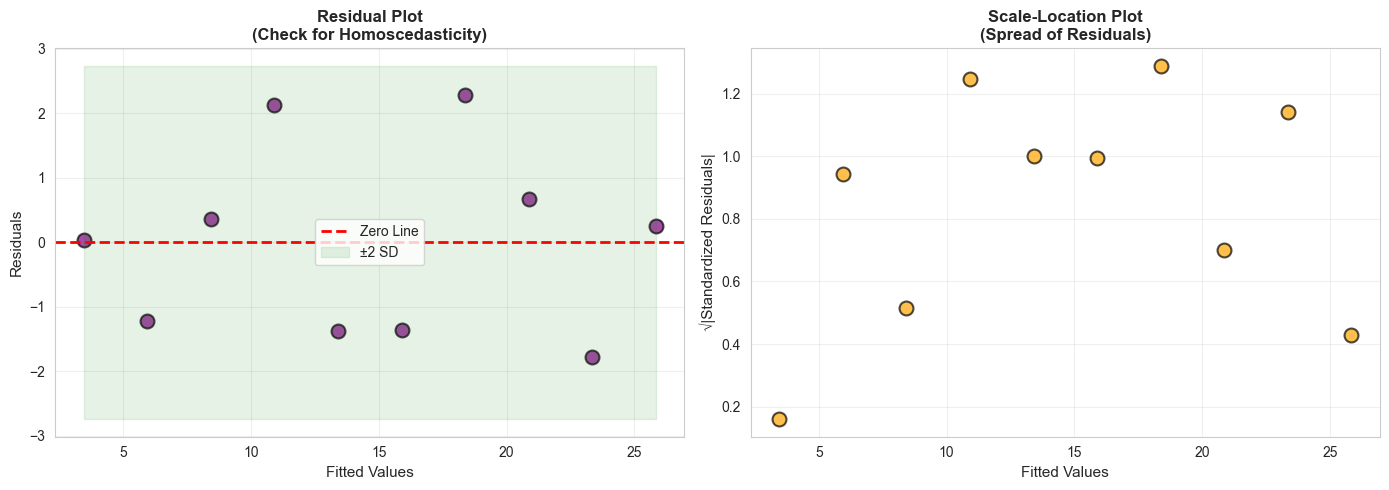


Residual Statistics:
Mean of residuals: -0.000000 (should be ≈ 0)
Std Dev of residuals: 1.3712
Min residual: -1.7868
Max residual: 2.2830


In [35]:
# Visualize Homoscedasticity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residual Plot (Homoscedasticity Check)
axes[0].scatter(y_pred, residuals, color='purple', s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
axes[0].fill_between(y_pred, -2*np.std(residuals), 2*np.std(residuals), alpha=0.1, color='green', label='±2 SD')
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residual Plot\n(Check for Homoscedasticity)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Scale-Location Plot (Square root of standardized residuals)
standardized_residuals = residuals / np.std(residuals)
axes[1].scatter(y_pred, np.sqrt(np.abs(standardized_residuals)), color='orange', s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
axes[1].set_xlabel('Fitted Values', fontsize=11)
axes[1].set_ylabel('√|Standardized Residuals|', fontsize=11)
axes[1].set_title('Scale-Location Plot\n(Spread of Residuals)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"Mean of residuals: {np.mean(residuals):.6f} (should be ≈ 0)")
print(f"Std Dev of residuals: {np.std(residuals):.4f}")
print(f"Min residual: {np.min(residuals):.4f}")
print(f"Max residual: {np.max(residuals):.4f}")

## 7. Correlation Analysis

### What is Correlation?
Correlation measures the strength and direction of the **linear relationship** between two variables.

**Pearson Correlation Coefficient:**
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$$

### Correlation Range
- **+1**: Perfect positive correlation
- **0 to +0.9**: Positive correlation
- **0**: No correlation
- **-0.9 to 0**: Negative correlation
- **-1**: Perfect negative correlation

### Correlation vs Regression
| Aspect | Correlation | Regression |
|--------|-------------|-----------|
| **Purpose** | Measures relationship strength | Predicts Y from X |
| **Symmetry** | Symmetric (X,Y) | Directional (X→Y) |
| **Output** | Single value (-1 to +1) | Equation & predictions |

**Important:** Correlation ≠ Causation!

In [36]:
# Calculate Pearson Correlation
correlation = np.corrcoef(X.flatten(), y)[0, 1]

print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"Correlation Strength: ", end="")

if abs(correlation) >= 0.9:
    print("Very Strong")
elif abs(correlation) >= 0.7:
    print("Strong")
elif abs(correlation) >= 0.5:
    print("Moderate")
elif abs(correlation) >= 0.3:
    print("Weak")
else:
    print("Very Weak")

print(f"\nDirection: {'Positive' if correlation > 0 else 'Negative'}")
print("=" * 50)

# Correlation Matrix (if multiple variables)
data_combined = np.column_stack((X.flatten(), y))
correlation_matrix = np.corrcoef(data_combined.T)
print("\nCorrelation Matrix:")
print(correlation_matrix)

CORRELATION ANALYSIS
Pearson Correlation Coefficient: 0.9821
Correlation Strength: Very Strong

Direction: Positive

Correlation Matrix:
[[1.        0.9820585]
 [0.9820585 1.       ]]


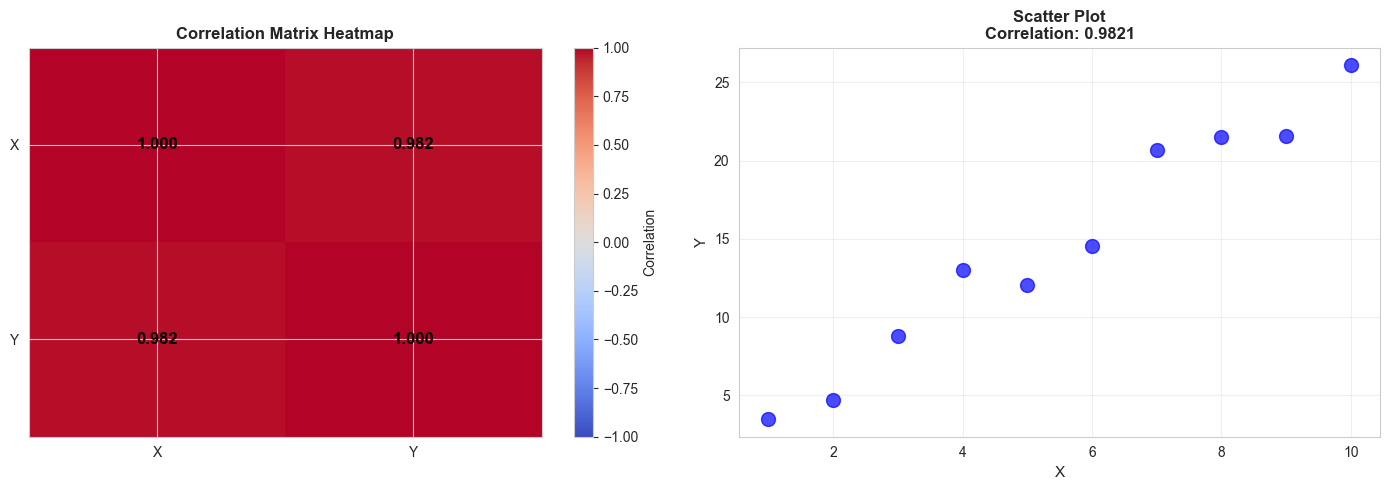

In [37]:
# Visualize Correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of correlation matrix
im = axes[0].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['X', 'Y'])
axes[0].set_yticklabels(['X', 'Y'])
axes[0].set_title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold')

# Add correlation values
for i in range(2):
    for j in range(2):
        text = axes[0].text(j, i, f'{correlation_matrix[i, j]:.3f}',
                           ha="center", va="center", color="black", fontsize=12, fontweight='bold')

plt.colorbar(im, ax=axes[0], label='Correlation')

# Scatter plot with correlation annotation
axes[1].scatter(X.flatten(), y, color='blue', s=100, alpha=0.7)
axes[1].set_xlabel('X', fontsize=11)
axes[1].set_ylabel('Y', fontsize=11)
axes[1].set_title(f'Scatter Plot\nCorrelation: {correlation:.4f}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Error Analysis in Machine Learning

### What is Error?
**Error** is the difference between predicted and actual values:
$$e_i = y_i - \hat{y}_i$$

### Types of Errors in ML

**1. Bias Error (Underfitting)**
- Model is too simple to capture patterns
- High training error + High test error
- Cause: Insufficient model complexity

**2. Variance Error (Overfitting)**
- Model fits noise in training data
- Low training error + High test error
- Cause: Too complex model or insufficient samples

**3. Irreducible Error**
- Natural randomness that can't be reduced
- Always present in any model

### Bias-Variance Tradeoff
$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

### Error Metrics Summary with Full Forms

| Abbr | Full Form | Formula | Interpretation |
|------|-----------|---------|---|
| **MAE** | Mean Absolute Error | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Average absolute deviation, robust to outliers |
| **MSE** | Mean Squared Error | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Average squared error, penalizes large errors more |
| **RMSE** | Root Mean Squared Error | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Same scale as target variable, interpretable |
| **R²** | Coefficient of Determination | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | Proportion of variance explained (0-1 scale) |
| **MAPE** | Mean Absolute Percentage Error | $\frac{1}{n}\sum\frac{\|y_i - \hat{y}_i\|}{y_i} \times 100\%$ | Percentage error, scale-independent |

### When to Use Which Metric?

| Metric | Best For | Advantages | Disadvantages |
|--------|----------|-----------|---|
| **MAE** | General purpose, outlier-resistant | Interpretable, symmetric | Doesn't penalize large errors |
| **MSE** | Optimization, squared errors matter | Differentiable, punishes large errors | Not in original scale, hard to interpret |
| **RMSE** | Most common, practical scenarios | Same scale as y, interpretable | Influenced by outliers |
| **R²** | Model comparison, proportion of fit | 0-1 scale, easy comparison | Doesn't indicate prediction quality alone |
| **MAPE** | Percentage basis, different scales | Scale-independent, percentage-based | Cannot handle zero values |

### Significance of Error in ML
✓ **Model Selection** - Compare different algorithms  
✓ **Hyperparameter Tuning** - Guide optimization  
✓ **Overfitting Detection** - High train/test error gap  
✓ **Feature Selection** - Identify important features  
✓ **Prediction Confidence** - Estimate reliability

In [38]:
# Detailed Error Analysis
print("=" * 60)
print("DETAILED ERROR ANALYSIS")
print("=" * 60)

# 1. Individual Errors
individual_errors = y - y_pred
print("\n1. INDIVIDUAL ERRORS:")
print(f"   Errors: {individual_errors}")

# 2. Error Statistics
print("\n2. ERROR STATISTICS:")
print(f"   Mean Error: {np.mean(individual_errors):.6f} (should be ≈ 0)")
print(f"   Std Dev of Errors: {np.std(individual_errors):.4f}")
print(f"   Max Error: {np.max(np.abs(individual_errors)):.4f}")
print(f"   Min Error: {np.min(np.abs(individual_errors)):.4f}")

# 3. Bias-Variance Components
print("\n3. BIAS-VARIANCE DECOMPOSITION:")
bias_component = (np.mean(y_pred) - np.mean(y))**2
variance_component = np.var(y_pred)
print(f"   Bias² (systematic error): {bias_component:.4f}")
print(f"   Variance (prediction spread): {variance_component:.4f}")

# 4. Error Distribution
print("\n4. ERROR DISTRIBUTION:")
print(f"   Positive Errors (Underestimation): {np.sum(individual_errors > 0)}")
print(f"   Negative Errors (Overestimation): {np.sum(individual_errors < 0)}")
print(f"   Zero Errors: {np.sum(individual_errors == 0)}")

print("=" * 60)

DETAILED ERROR ANALYSIS

1. INDIVIDUAL ERRORS:
   Errors: [ 0.03520274 -1.22095343  0.36475299  2.12923637 -1.37132934 -1.35749577
  2.28300452  0.67324909 -1.78676839  0.25110121]

2. ERROR STATISTICS:
   Mean Error: -0.000000 (should be ≈ 0)
   Std Dev of Errors: 1.3712
   Max Error: 2.2830
   Min Error: 0.0352

3. BIAS-VARIANCE DECOMPOSITION:
   Bias² (systematic error): 0.0000
   Variance (prediction spread): 50.9948

4. ERROR DISTRIBUTION:
   Positive Errors (Underestimation): 6
   Negative Errors (Overestimation): 4
   Zero Errors: 0


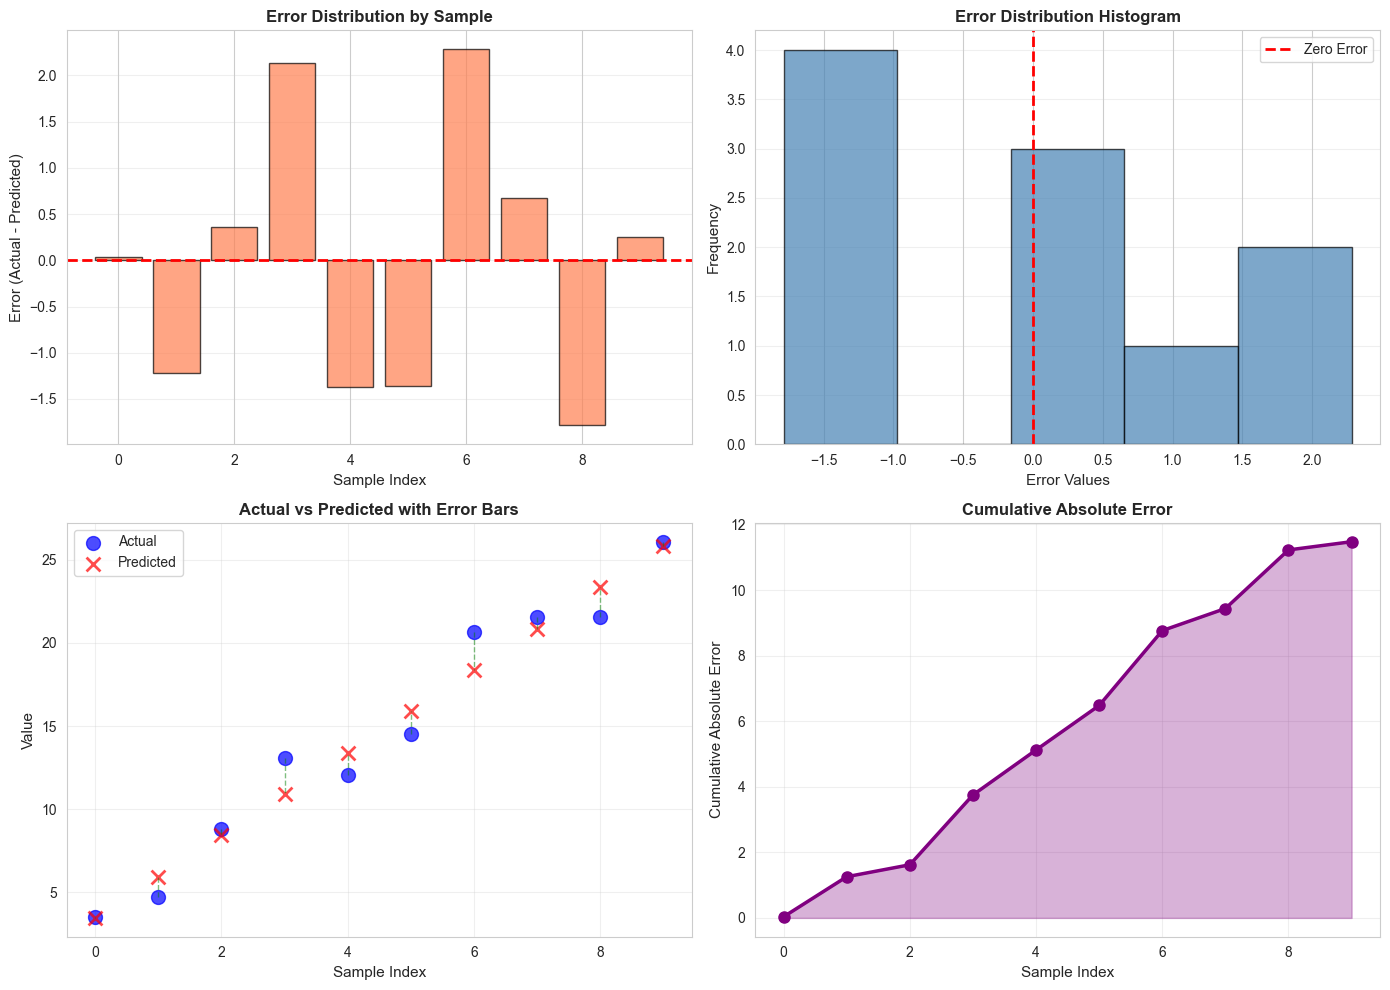

In [39]:
# Visualize Error Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Error Distribution
axes[0, 0].bar(range(len(individual_errors)), individual_errors, color='coral', alpha=0.7, edgecolor='black')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Sample Index', fontsize=11)
axes[0, 0].set_ylabel('Error (Actual - Predicted)', fontsize=11)
axes[0, 0].set_title('Error Distribution by Sample', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Error Histogram
axes[0, 1].hist(individual_errors, bins=5, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 1].set_xlabel('Error Values', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Error Distribution Histogram', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Actual vs Predicted with Error Bars
axes[1, 0].scatter(range(len(y)), y, color='blue', s=100, label='Actual', alpha=0.7, marker='o')
axes[1, 0].scatter(range(len(y_pred)), y_pred, color='red', s=100, label='Predicted', alpha=0.7, marker='x', linewidth=2)
for i in range(len(y)):
    axes[1, 0].plot([i, i], [y[i], y_pred[i]], 'g--', alpha=0.5, linewidth=1)
axes[1, 0].set_xlabel('Sample Index', fontsize=11)
axes[1, 0].set_ylabel('Value', fontsize=11)
axes[1, 0].set_title('Actual vs Predicted with Error Bars', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Error
cumulative_error = np.cumsum(np.abs(individual_errors))
axes[1, 1].plot(range(len(cumulative_error)), cumulative_error, color='purple', linewidth=2.5, marker='o', markersize=8)
axes[1, 1].fill_between(range(len(cumulative_error)), cumulative_error, alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Sample Index', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Absolute Error', fontsize=11)
axes[1, 1].set_title('Cumulative Absolute Error', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Practical Example: Expected vs Actual Student Marks

### Scenario
A model predicts student exam marks based on study hours. We have 10 students with:
- **Expected Marks (Predicted):** Model predictions
- **Actual Marks:** Real exam scores

### Error Calculations

**1. Individual Error:**
$$e_i = \text{Actual}_i - \text{Expected}_i$$

**2. Mean Error (ME):**
$$ME = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)$$
- Should be close to 0
- Can mask over/under predictions

**3. Mean Absolute Error (MAE):**
$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$
- Always positive
- Interpretable (avg marks error)

**4. Root Mean Squared Error (RMSE):**
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$
- Penalizes large errors more
- Same scale as marks

**5. R² Score:**
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$
- 0-1 scale
- 1 = Perfect prediction, 0 = No better than mean

In [40]:
# Practical Example: Expected vs Actual Student Marks
import pandas as pd

# Create sample data: 10 students
students = [f'Student_{i+1}' for i in range(10)]
study_hours = np.array([2, 3, 4, 5, 6, 7, 3, 5, 7, 8])
expected_marks = 40 + 8 * study_hours  # Model prediction: Marks = 40 + 8*Hours
actual_marks = np.array([50, 60, 75, 82, 95, 100, 65, 78, 92, 105])

# Create DataFrame
marks_df = pd.DataFrame({
    'Student': students,
    'Study_Hours': study_hours,
    'Expected_Marks': expected_marks,
    'Actual_Marks': actual_marks
})

# Calculate Error Metrics
marks_df['Error'] = marks_df['Actual_Marks'] - marks_df['Expected_Marks']
marks_df['Abs_Error'] = np.abs(marks_df['Error'])
marks_df['Squared_Error'] = marks_df['Error'] ** 2

print("=" * 100)
print("EXPECTED vs ACTUAL MARKS - 10 STUDENTS")
print("=" * 100)
print(marks_df.to_string(index=False))
print("=" * 100)

EXPECTED vs ACTUAL MARKS - 10 STUDENTS
   Student  Study_Hours  Expected_Marks  Actual_Marks  Error  Abs_Error  Squared_Error
 Student_1            2              56            50     -6          6             36
 Student_2            3              64            60     -4          4             16
 Student_3            4              72            75      3          3              9
 Student_4            5              80            82      2          2              4
 Student_5            6              88            95      7          7             49
 Student_6            7              96           100      4          4             16
 Student_7            3              64            65      1          1              1
 Student_8            5              80            78     -2          2              4
 Student_9            7              96            92     -4          4             16
Student_10            8             104           105      1          1              1


In [41]:
# Calculate Error Metrics for Marks Prediction
actual = marks_df['Actual_Marks'].values
expected = marks_df['Expected_Marks'].values

# 1. Mean Error
me = np.mean(actual - expected)

# 2. Mean Absolute Error
mae_marks = np.mean(np.abs(actual - expected))

# 3. Root Mean Squared Error
rmse_marks = np.sqrt(np.mean((actual - expected)**2))

# 4. R² Score
ss_res = np.sum((actual - expected)**2)
ss_tot = np.sum((actual - np.mean(actual))**2)
r2_marks = 1 - (ss_res / ss_tot)

# 5. Mean Percentage Error
mape = np.mean(np.abs((actual - expected) / actual)) * 100

print("\n" + "=" * 70)
print("ERROR METRICS CALCULATION EXPLAINED")
print("=" * 70)

print(f"\n1. MEAN ERROR (ME):")
print(f"   ME = (1/n) × Σ(Actual - Expected)")
print(f"   ME = {me:.2f} marks")
print(f"   Interpretation: On average, predictions are {'over' if me < 0 else 'under'}estimated by {abs(me):.2f} marks")

print(f"\n2. MEAN ABSOLUTE ERROR (MAE):")
print(f"   MAE = (1/n) × Σ|Actual - Expected|")
print(f"   MAE = {mae_marks:.2f} marks")
print(f"   Interpretation: On average, predictions deviate by ±{mae_marks:.2f} marks from actual")

print(f"\n3. ROOT MEAN SQUARED ERROR (RMSE):")
print(f"   RMSE = √[(1/n) × Σ(Actual - Expected)²]")
print(f"   RMSE = {rmse_marks:.2f} marks")
print(f"   Interpretation: Typical prediction error is ±{rmse_marks:.2f} marks (penalizes large errors)")

print(f"\n4. R² SCORE:")
print(f"   R² = 1 - [Σ(Actual - Expected)² / Σ(Actual - Mean)²]")
print(f"   R² = {r2_marks:.4f}")
print(f"   Interpretation: Model explains {r2_marks*100:.2f}% of variance in marks")

print(f"\n5. MEAN ABSOLUTE PERCENTAGE ERROR (MAPE):")
print(f"   MAPE = (1/n) × Σ|Actual - Expected| / Actual × 100%")
print(f"   MAPE = {mape:.2f}%")
print(f"   Interpretation: Predictions are off by approximately {mape:.2f}% on average")

print("=" * 70)


ERROR METRICS CALCULATION EXPLAINED

1. MEAN ERROR (ME):
   ME = (1/n) × Σ(Actual - Expected)
   ME = 0.20 marks
   Interpretation: On average, predictions are underestimated by 0.20 marks

2. MEAN ABSOLUTE ERROR (MAE):
   MAE = (1/n) × Σ|Actual - Expected|
   MAE = 3.40 marks
   Interpretation: On average, predictions deviate by ±3.40 marks from actual

3. ROOT MEAN SQUARED ERROR (RMSE):
   RMSE = √[(1/n) × Σ(Actual - Expected)²]
   RMSE = 3.90 marks
   Interpretation: Typical prediction error is ±3.90 marks (penalizes large errors)

4. R² SCORE:
   R² = 1 - [Σ(Actual - Expected)² / Σ(Actual - Mean)²]
   R² = 0.9485
   Interpretation: Model explains 94.85% of variance in marks

5. MEAN ABSOLUTE PERCENTAGE ERROR (MAPE):
   MAPE = (1/n) × Σ|Actual - Expected| / Actual × 100%
   MAPE = 4.59%
   Interpretation: Predictions are off by approximately 4.59% on average


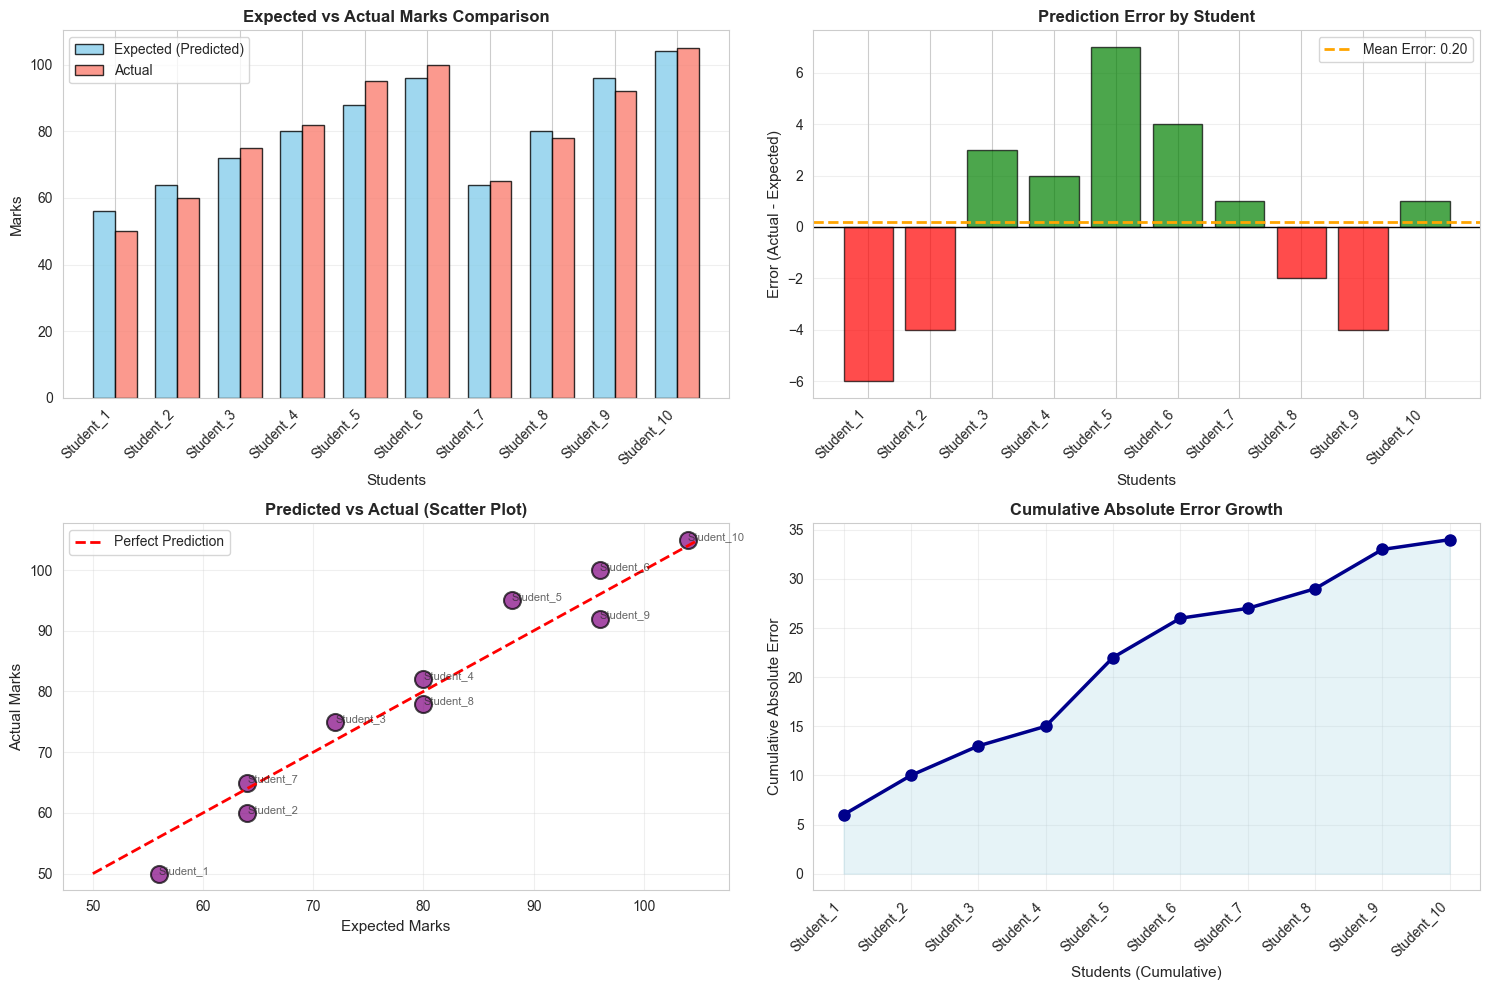


✓ Visualization shows:
  - Plot 1: Side-by-side comparison of predictions vs actual marks
  - Plot 2: Individual errors (positive = underestimation, negative = overestimation)
  - Plot 3: Correlation between predicted and actual (closer to line = better prediction)
  - Plot 4: Cumulative error trend across students


In [42]:
# Visualize Marks Prediction with Errors
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Expected vs Actual Marks
x_pos = np.arange(len(students))
width = 0.35
axes[0, 0].bar(x_pos - width/2, expected, width, label='Expected (Predicted)', color='skyblue', alpha=0.8, edgecolor='black')
axes[0, 0].bar(x_pos + width/2, actual, width, label='Actual', color='salmon', alpha=0.8, edgecolor='black')
axes[0, 0].set_xlabel('Students', fontsize=11)
axes[0, 0].set_ylabel('Marks', fontsize=11)
axes[0, 0].set_title('Expected vs Actual Marks Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(students, rotation=45, ha='right')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Error by Student
errors = marks_df['Error'].values
colors = ['green' if e >= 0 else 'red' for e in errors]
axes[0, 1].bar(range(len(students)), errors, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_xlabel('Students', fontsize=11)
axes[0, 1].set_ylabel('Error (Actual - Expected)', fontsize=11)
axes[0, 1].set_title('Prediction Error by Student', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(len(students)))
axes[0, 1].set_xticklabels(students, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(y=np.mean(errors), color='orange', linestyle='--', linewidth=2, label=f'Mean Error: {np.mean(errors):.2f}')
axes[0, 1].legend(fontsize=10)

# Plot 3: Scatter Plot with Perfect Prediction Line
axes[1, 0].scatter(expected, actual, s=150, color='purple', alpha=0.7, edgecolors='black', linewidth=1.5)
min_val = min(expected.min(), actual.min())
max_val = max(expected.max(), actual.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
for i, student in enumerate(students):
    axes[1, 0].annotate(student, (expected[i], actual[i]), fontsize=8, alpha=0.7)
axes[1, 0].set_xlabel('Expected Marks', fontsize=11)
axes[1, 0].set_ylabel('Actual Marks', fontsize=11)
axes[1, 0].set_title('Predicted vs Actual (Scatter Plot)', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Error Analysis
cumulative_abs_error = np.cumsum(np.abs(errors))
axes[1, 1].plot(range(len(students)), cumulative_abs_error, marker='o', linewidth=2.5, markersize=8, color='darkblue')
axes[1, 1].fill_between(range(len(students)), cumulative_abs_error, alpha=0.3, color='lightblue')
axes[1, 1].set_xlabel('Students (Cumulative)', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Absolute Error', fontsize=11)
axes[1, 1].set_title('Cumulative Absolute Error Growth', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(students)))
axes[1, 1].set_xticklabels(students, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualization shows:")
print("  - Plot 1: Side-by-side comparison of predictions vs actual marks")
print("  - Plot 2: Individual errors (positive = underestimation, negative = overestimation)")
print("  - Plot 3: Correlation between predicted and actual (closer to line = better prediction)")
print("  - Plot 4: Cumulative error trend across students")